In [ ]:
from csv import DictReader

with open('data/combustdb_master.csv', 'r') as csv_file:
    reader = DictReader(csv_file)
    rows = [r for r in reader]
csv_file.close()

compounds = [r for r in rows if r['properties.cetane_number.value'] != '-']
print(len(compounds))

408


In [2]:
from alvadescpy import smiles_to_descriptors

descriptors = [smiles_to_descriptors(c['canonical_smiles']) for c in compounds]

In [3]:
import pandas as pd
import numpy as np

df = pd.DataFrame(descriptors)

X = df.values
for i in range(len(X)):
    for j in range(len(X[i])):
        if X[i][j] == 'na':
            X[i][j] = 0.0
X = X.astype('float32')

y = np.array([[float(c['properties.cetane_number.value'])] for c in compounds], dtype='float32')

print(X.shape, y.shape)

(408, 5305) (408, 1)


In [4]:
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore
import numpy as np

scaler = StandardScaler()
scaler.fit(X)
X_norm = scaler.transform(X)

scores = zscore(X_norm, axis=1)

sample_score_sums = np.sum(scores, axis=1)

In [5]:
with open('pred_results.csv', 'r') as csv_file:
    reader = DictReader(csv_file)
    results = [r for r in reader]
csv_file.close()

In [6]:
pred = [float(r['pred']) for r in results]
actual = [float(r['actual']) for r in results]

abs_err = [abs(pred[i] - actual[i]) for i in range(len(pred))]
err = [pred[i] - actual[i] for i in range(len(pred))]

SyntaxError: invalid syntax (877675190.py, line 5)

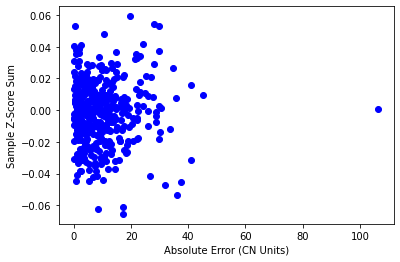

In [ ]:
from matplotlib import pyplot as plt

plt.scatter(abs_err, sample_score_sums, color='blue')
plt.xlabel('Absolute Error (CN Units)')
plt.ylabel('Sample Z-Score Sum')
plt.show()

In [ ]:
plt.clf()
plt.scatter(err, sample_score_sums, color='blue')
plt.xlabel('Error (CN Units)')
plt.ylabel('Sample Z-Score Sum')
plt.show()